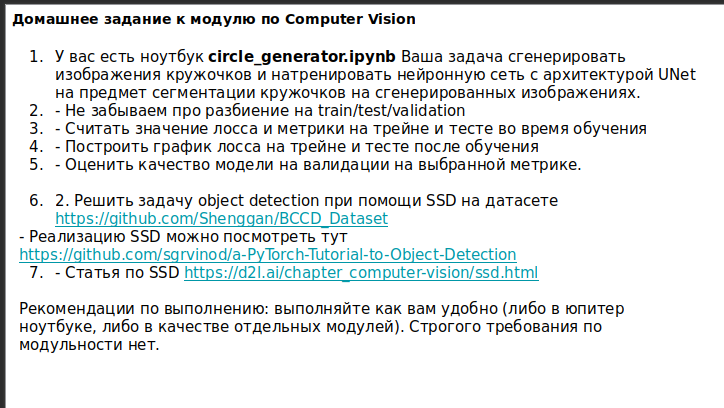

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


class BaseDataProvider(object):
    channels = 1
    n_class = 2

    def __init__(self, a_min=None, a_max=None):
        self.a_min = a_min if a_min is not None else -np.inf
        self.a_max = a_max if a_min is not None else np.inf

    def _load_data_and_label(self):
        data, label = self._next_data()

        train_data = self._process_data(data)
        labels = self._process_labels(label)

        train_data, labels = self._post_process(train_data, labels)

        nx = train_data.shape[1]
        ny = train_data.shape[0]

        return train_data.reshape(1, ny, nx, self.channels), labels.reshape(1, ny, nx, self.n_class),

    def _process_labels(self, label):
        if self.n_class == 2:
            nx = label.shape[1]
            ny = label.shape[0]
            labels = np.zeros((ny, nx, self.n_class), dtype=np.float32)

            # It is the responsibility of the child class to make sure that the label
            # is a boolean array, but we a chech here just in case.
            if label.dtype != 'bool':
                label = label.astype(bool)

            labels[..., 1] = label
            labels[..., 0] = ~label
            return labels

        return label

    def _process_data(self, data):
        # normalization
        data = np.clip(np.fabs(data), self.a_min, self.a_max)
        data -= np.amin(data)

        if np.amax(data) != 0:
            data /= np.amax(data)

        return data

    def _post_process(self, data, labels):
        """
        Post processing hook that can be used for data augmentation
        :param data: the data array
        :param labels: the label array
        """
        return data, labels

    def __call__(self, n):
        train_data, labels = self._load_data_and_label()
        nx = train_data.shape[1]
        ny = train_data.shape[2]

        X = np.zeros((n, nx, ny, self.channels))
        Y = np.zeros((n, nx, ny, self.n_class))

        X[0] = train_data
        Y[0] = labels
        for i in range(1, n):
            train_data, labels = self._load_data_and_label()
            X[i] = train_data
            Y[i] = labels

        return X, Y

class GrayScaleDataProvider(BaseDataProvider):
    channels = 1
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(GrayScaleDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class=3

    def _next_data(self):
        return create_image_and_label(self.nx, self.ny, **self.kwargs)

class RgbDataProvider(BaseDataProvider):
    channels = 3
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(RgbDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class=3


    def _next_data(self):
        data, label = create_image_and_label(self.nx, self.ny, **self.kwargs)
        return to_rgb(data), label

def create_image_and_label(nx,ny, cnt = 10, r_min = 5, r_max = 50, border = 92, sigma = 20, rectangles=False):


    image = np.ones((nx, ny, 1))
    label = np.zeros((nx, ny, 3), dtype=bool)
    mask = np.zeros((nx, ny), dtype=bool)
    for _ in range(cnt):
        a = np.random.randint(border, nx-border)
        b = np.random.randint(border, ny-border)
        r = np.random.randint(r_min, r_max)
        h = np.random.randint(1,255)

        y,x = np.ogrid[-a:nx-a, -b:ny-b]
        m = x*x + y*y <= r*r
        mask = np.logical_or(mask, m)

        image[m] = h

    label[mask, 1] = 1

    if rectangles:
        mask = np.zeros((nx, ny), dtype=bool)
        for _ in range(cnt//2):
            a = np.random.randint(nx)
            b = np.random.randint(ny)
            r =  np.random.randint(r_min, r_max)
            h = np.random.randint(1,255)

            m = np.zeros((nx, ny), dtype=bool)
            m[a:a+r, b:b+r] = True
            mask = np.logical_or(mask, m)
            image[m] = h

        label[mask, 2] = 1

        label[..., 0] = ~(np.logical_or(label[...,1], label[...,2]))

    image += np.random.normal(scale=sigma, size=image.shape)
    image -= np.amin(image)
    image /= np.amax(image)

    if rectangles:
        return image, label
    else:
        return image, label[..., 1]




def to_rgb(img):
    img = img.reshape(img.shape[0], img.shape[1])
    img[np.isnan(img)] = 0
    img -= np.amin(img)
    img /= np.amax(img)
    blue = np.clip(4*(0.75-img), 0, 1)
    red  = np.clip(4*(img-0.25), 0, 1)
    green= np.clip(44*np.fabs(img-0.5)-1., 0, 1)
    rgb = np.stack((red, green, blue), axis=2)
    return rgb


### 1. Подготовка
Генерация синтетических данных

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

nx, ny = 256, 256
generator = GrayScaleDataProvider(nx, ny, cnt=20)

X_train_np, Y_train_np = generator(800)
X_val_np, Y_val_np = generator(100)
X_test_np, Y_test_np = generator(100)

X_train = torch.FloatTensor(X_train_np).permute(0, 3, 1, 2)
Y_train = torch.FloatTensor(Y_train_np).permute(0, 3, 1, 2)
X_val = torch.FloatTensor(X_val_np).permute(0, 3, 1, 2)
Y_val = torch.FloatTensor(Y_val_np).permute(0, 3, 1, 2)
X_test = torch.FloatTensor(X_test_np).permute(0, 3, 1, 2)
Y_test = torch.FloatTensor(Y_test_np).permute(0, 3, 1, 2)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=8, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=8, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=8, shuffle=False)

print(f"Train shapes: X={X_train.shape}, Y={Y_train.shape}")

Генерация данных...
Train shapes: X=torch.Size([800, 1, 256, 256]), Y=torch.Size([800, 2, 256, 256])


### 2. Архитектура UNet

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_classes=2):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)
        
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)
        
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)
        
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, out_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        x5 = self.bottleneck(self.pool(x4))

        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.up_conv1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.up_conv2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up_conv3(x)

        x = self.up4(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up_conv4(x)

        out = self.out_conv(x)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=1, out_classes=2).to(device)

dummy_x = torch.randn(2, 1, 256, 256).to(device)
print(f"Device: {device} | UNet test output: {model(dummy_x).shape}")

Device: cuda | UNet test output: torch.Size([2, 2, 256, 256])


### 3. Обучение и оценка качества

Обучение UNet...
Epoch 1/5 | Tr_Loss: 0.2367 | Tr_IoU: 0.8819 | Val_Loss: 0.1361 | Val_IoU: 0.8838
Epoch 2/5 | Tr_Loss: 0.0965 | Tr_IoU: 0.9035 | Val_Loss: 0.1629 | Val_IoU: 0.8963
Epoch 3/5 | Tr_Loss: 0.0683 | Tr_IoU: 0.9227 | Val_Loss: 0.0649 | Val_IoU: 0.9218
Epoch 4/5 | Tr_Loss: 0.0471 | Tr_IoU: 0.9420 | Val_Loss: 0.0474 | Val_IoU: 0.9382
Epoch 5/5 | Tr_Loss: 0.0334 | Tr_IoU: 0.9570 | Val_Loss: 0.0401 | Val_IoU: 0.9527


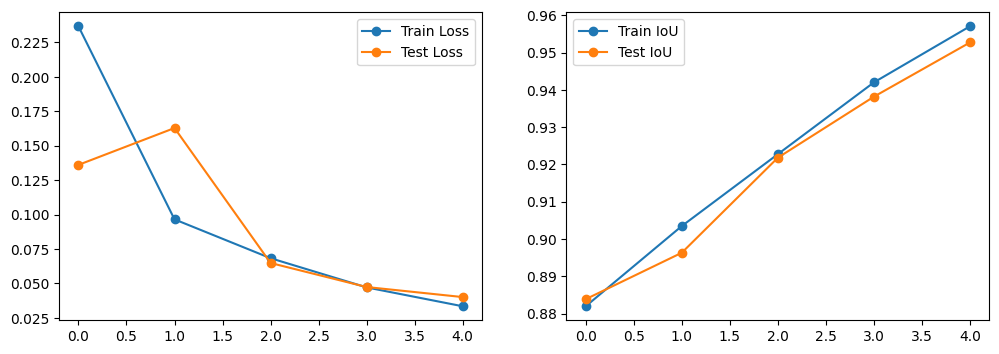

Final Val IoU: 0.9549


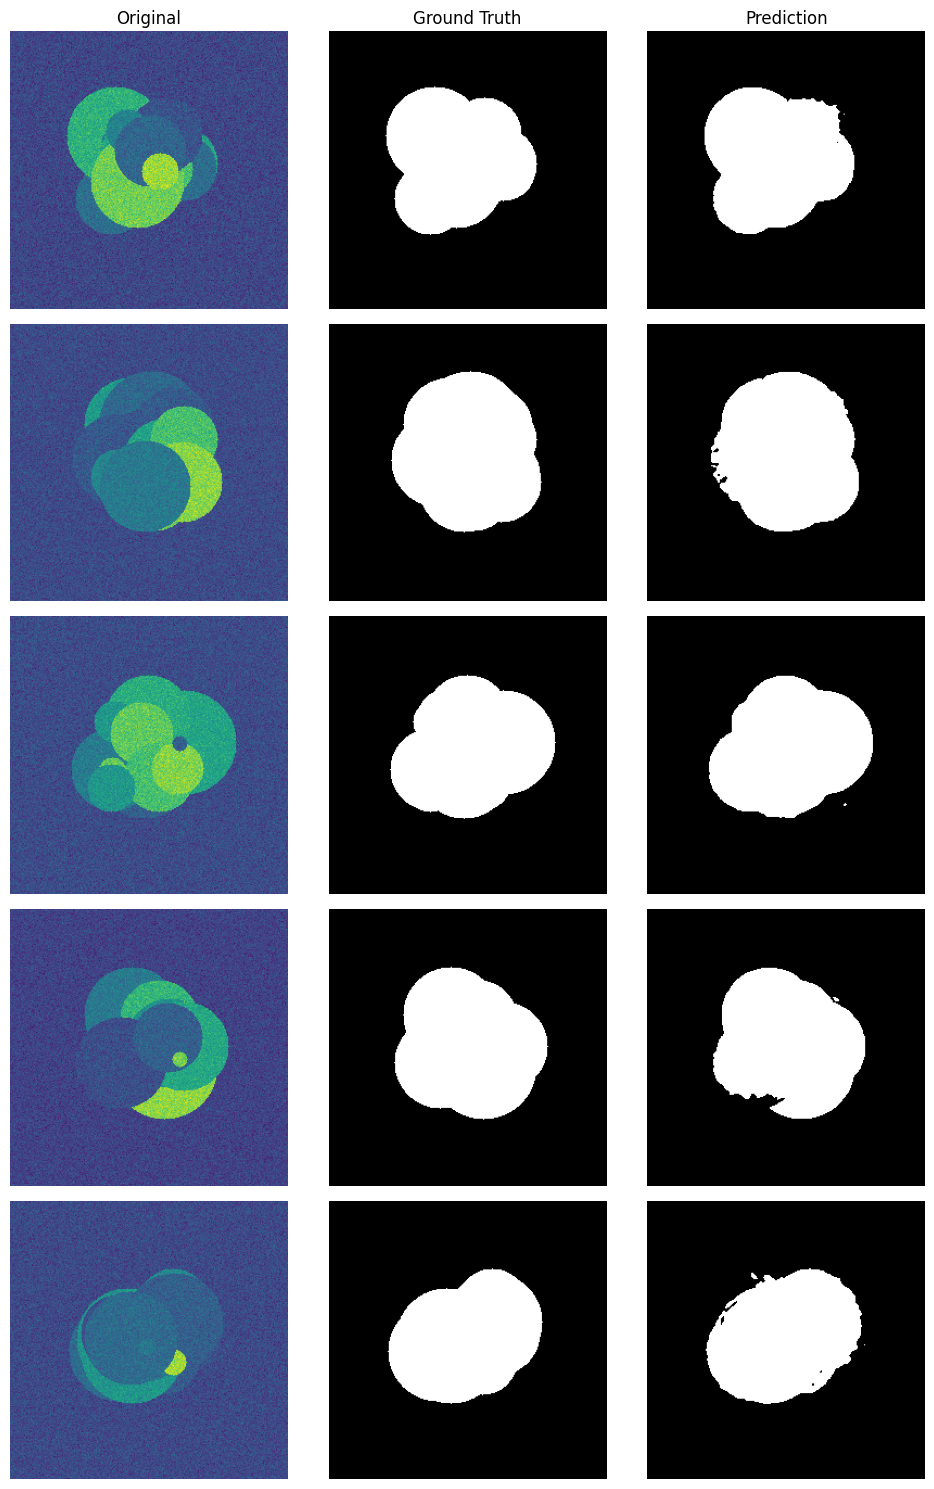

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

def calculate_iou(preds, labels, threshold=0.5):
    probs = torch.sigmoid(preds)[:, 1, :, :]
    preds_bin = (probs > threshold).float()
    labels_bin = labels[:, 1, :, :] 
    intersection = (preds_bin * labels_bin).sum(dim=(1, 2))
    union = preds_bin.sum(dim=(1, 2)) + labels_bin.sum(dim=(1, 2)) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6) 
    return iou.mean().item()

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 5
train_losses, test_losses, train_ious, test_ious = [], [], [], []

print("Обучение UNet")

for epoch in range(epochs):
    model.train()
    epoch_loss, epoch_iou = 0, 0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, Y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        epoch_iou += calculate_iou(preds, Y_batch)
        
    train_losses.append(epoch_loss / len(train_loader))
    train_ious.append(epoch_iou / len(train_loader))
    
    model.eval()
    test_loss, test_iou = 0, 0
    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, Y_batch)
            test_loss += loss.item()
            test_iou += calculate_iou(preds, Y_batch)
            
    test_losses.append(test_loss / len(test_loader))
    test_ious.append(test_iou / len(test_loader))
    print(f"Epoch {epoch+1}/{epochs} | Tr_Loss: {train_losses[-1]:.4f} | Tr_IoU: {train_ious[-1]:.4f} | Val_Loss: {test_losses[-1]:.4f} | Val_IoU: {test_ious[-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_losses, label='Train Loss', marker='o')
ax[0].plot(test_losses, label='Test Loss', marker='o')
ax[0].legend()
ax[1].plot(train_ious, label='Train IoU', marker='o')
ax[1].plot(test_ious, label='Test IoU', marker='o')
ax[1].legend()
plt.show()

model.eval()
val_iou = 0
with torch.no_grad():
    for X_batch, Y_batch in val_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        val_iou += calculate_iou(model(X_batch), Y_batch)

print(f"Final Val IoU: {val_iou / len(val_loader):.4f}")

with torch.no_grad():
    sample_imgs, sample_masks = next(iter(val_loader))
    sample_imgs = sample_imgs.to(device)
    pred_masks = model(sample_imgs)

fig, axes = plt.subplots(5, 3, figsize=(10, 15))

for i in range(5):
    img_show = sample_imgs[i, 0].cpu().numpy()
    true_mask_show = sample_masks[i, 1].numpy()
    pred_mask_show = (torch.sigmoid(pred_masks)[i, 1] > 0.5).cpu().float().numpy()

    axes[i, 0].imshow(img_show, cmap='viridis')
    axes[i, 1].imshow(true_mask_show, cmap='gray')
    axes[i, 2].imshow(pred_mask_show, cmap='gray')
    
    axes[i, 0].axis('off')
    axes[i, 1].axis('off')
    axes[i, 2].axis('off')

axes[0, 0].set_title('Original')
axes[0, 1].set_title('Ground Truth')
axes[0, 2].set_title('Prediction')

plt.tight_layout()
plt.show()

Был такой случай когда сразу у двух кругов совпал цвет почти 1 в 1
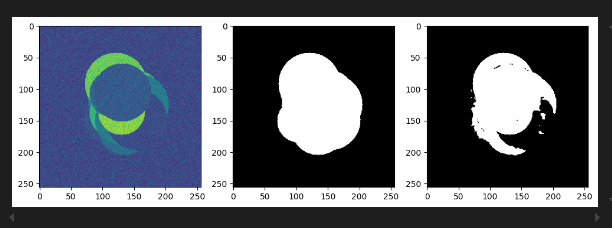

в остальных случаях хорошо работает

### 4. Object Detection (SSD)

In [9]:
import os
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import torchvision.transforms.functional as FT

class BCCDDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, split='train'):
        self.image_dir = os.path.join(data_dir, 'BCCD', 'JPEGImages')
        self.annot_dir = os.path.join(data_dir, 'BCCD', 'Annotations')
        split_file = os.path.join(data_dir, 'BCCD', 'ImageSets', 'Main', f'{split}.txt')
        with open(split_file, 'r') as f:
            self.image_ids = [line.strip() for line in f.readlines()]
        self.classes = ['background', 'RBC', 'WBC', 'Platelets']
        self.class_to_id = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image = Image.open(os.path.join(self.image_dir, f'{image_id}.jpg')).convert("RGB")
        root = ET.parse(os.path.join(self.annot_dir, f'{image_id}.xml')).getroot()
        
        boxes, labels = [], []
        for obj in root.findall('object'):
            label_name = obj.find('name').text
            if label_name not in self.class_to_id: continue
            
            bndbox = obj.find('bndbox')
            xmin, ymin = float(bndbox.find('xmin').text), float(bndbox.find('ymin').text)
            xmax, ymax = float(bndbox.find('xmax').text), float(bndbox.find('ymax').text)
            
            if xmax <= xmin or ymax <= ymin: continue
                
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.class_to_id[label_name])
            
        boxes = torch.FloatTensor(boxes).reshape(-1, 4)
        return FT.to_tensor(image), boxes, torch.LongTensor(labels)

def collate_fn_ssd(batch):
    images, targets = [], []
    for b in batch:
        images.append(b[0])
        targets.append({'boxes': b[1], 'labels': b[2]})
    return images, targets

train_dataset_ssd = BCCDDataset('./BCCD_Dataset', 'train')
val_dataset_ssd = BCCDDataset('./BCCD_Dataset', 'val')
train_loader_ssd = DataLoader(train_dataset_ssd, batch_size=4, shuffle=True, collate_fn=collate_fn_ssd)
val_loader_ssd = DataLoader(val_dataset_ssd, batch_size=4, shuffle=False, collate_fn=collate_fn_ssd)

print(f"SSD Data loaded. Train size: {len(train_dataset_ssd)}")

SSD Data loaded. Train size: 205


### 5. Обучение модели SSD

Обучение SSD...
Epoch 1/50 | Loss: 7.1097
Epoch 2/50 | Loss: 4.3562
Epoch 3/50 | Loss: 4.2382
Epoch 4/50 | Loss: 4.1812
Epoch 5/50 | Loss: 4.1249
Epoch 6/50 | Loss: 4.0618
Epoch 7/50 | Loss: 3.9610
Epoch 8/50 | Loss: 3.8646
Epoch 9/50 | Loss: 3.7864
Epoch 10/50 | Loss: 3.7013
Epoch 11/50 | Loss: 3.5162
Epoch 12/50 | Loss: 3.2420
Epoch 13/50 | Loss: 3.0232
Epoch 14/50 | Loss: 2.7893
Epoch 15/50 | Loss: 2.5546
Epoch 16/50 | Loss: 2.3635
Epoch 17/50 | Loss: 2.1489
Epoch 18/50 | Loss: 1.9459
Epoch 19/50 | Loss: 1.7679
Epoch 20/50 | Loss: 1.6351
Epoch 21/50 | Loss: 1.4851
Epoch 22/50 | Loss: 1.3636
Epoch 23/50 | Loss: 1.2088
Epoch 24/50 | Loss: 1.0772
Epoch 25/50 | Loss: 0.9888
Epoch 26/50 | Loss: 0.8533
Epoch 27/50 | Loss: 0.7704
Epoch 28/50 | Loss: 0.7017
Epoch 29/50 | Loss: 0.6037
Epoch 30/50 | Loss: 0.5445
Epoch 31/50 | Loss: 0.4982
Epoch 32/50 | Loss: 0.4423
Epoch 33/50 | Loss: 0.4092
Epoch 34/50 | Loss: 0.3833
Epoch 35/50 | Loss: 0.3455
Epoch 36/50 | Loss: 0.3063
Epoch 37/50 | Loss: 0

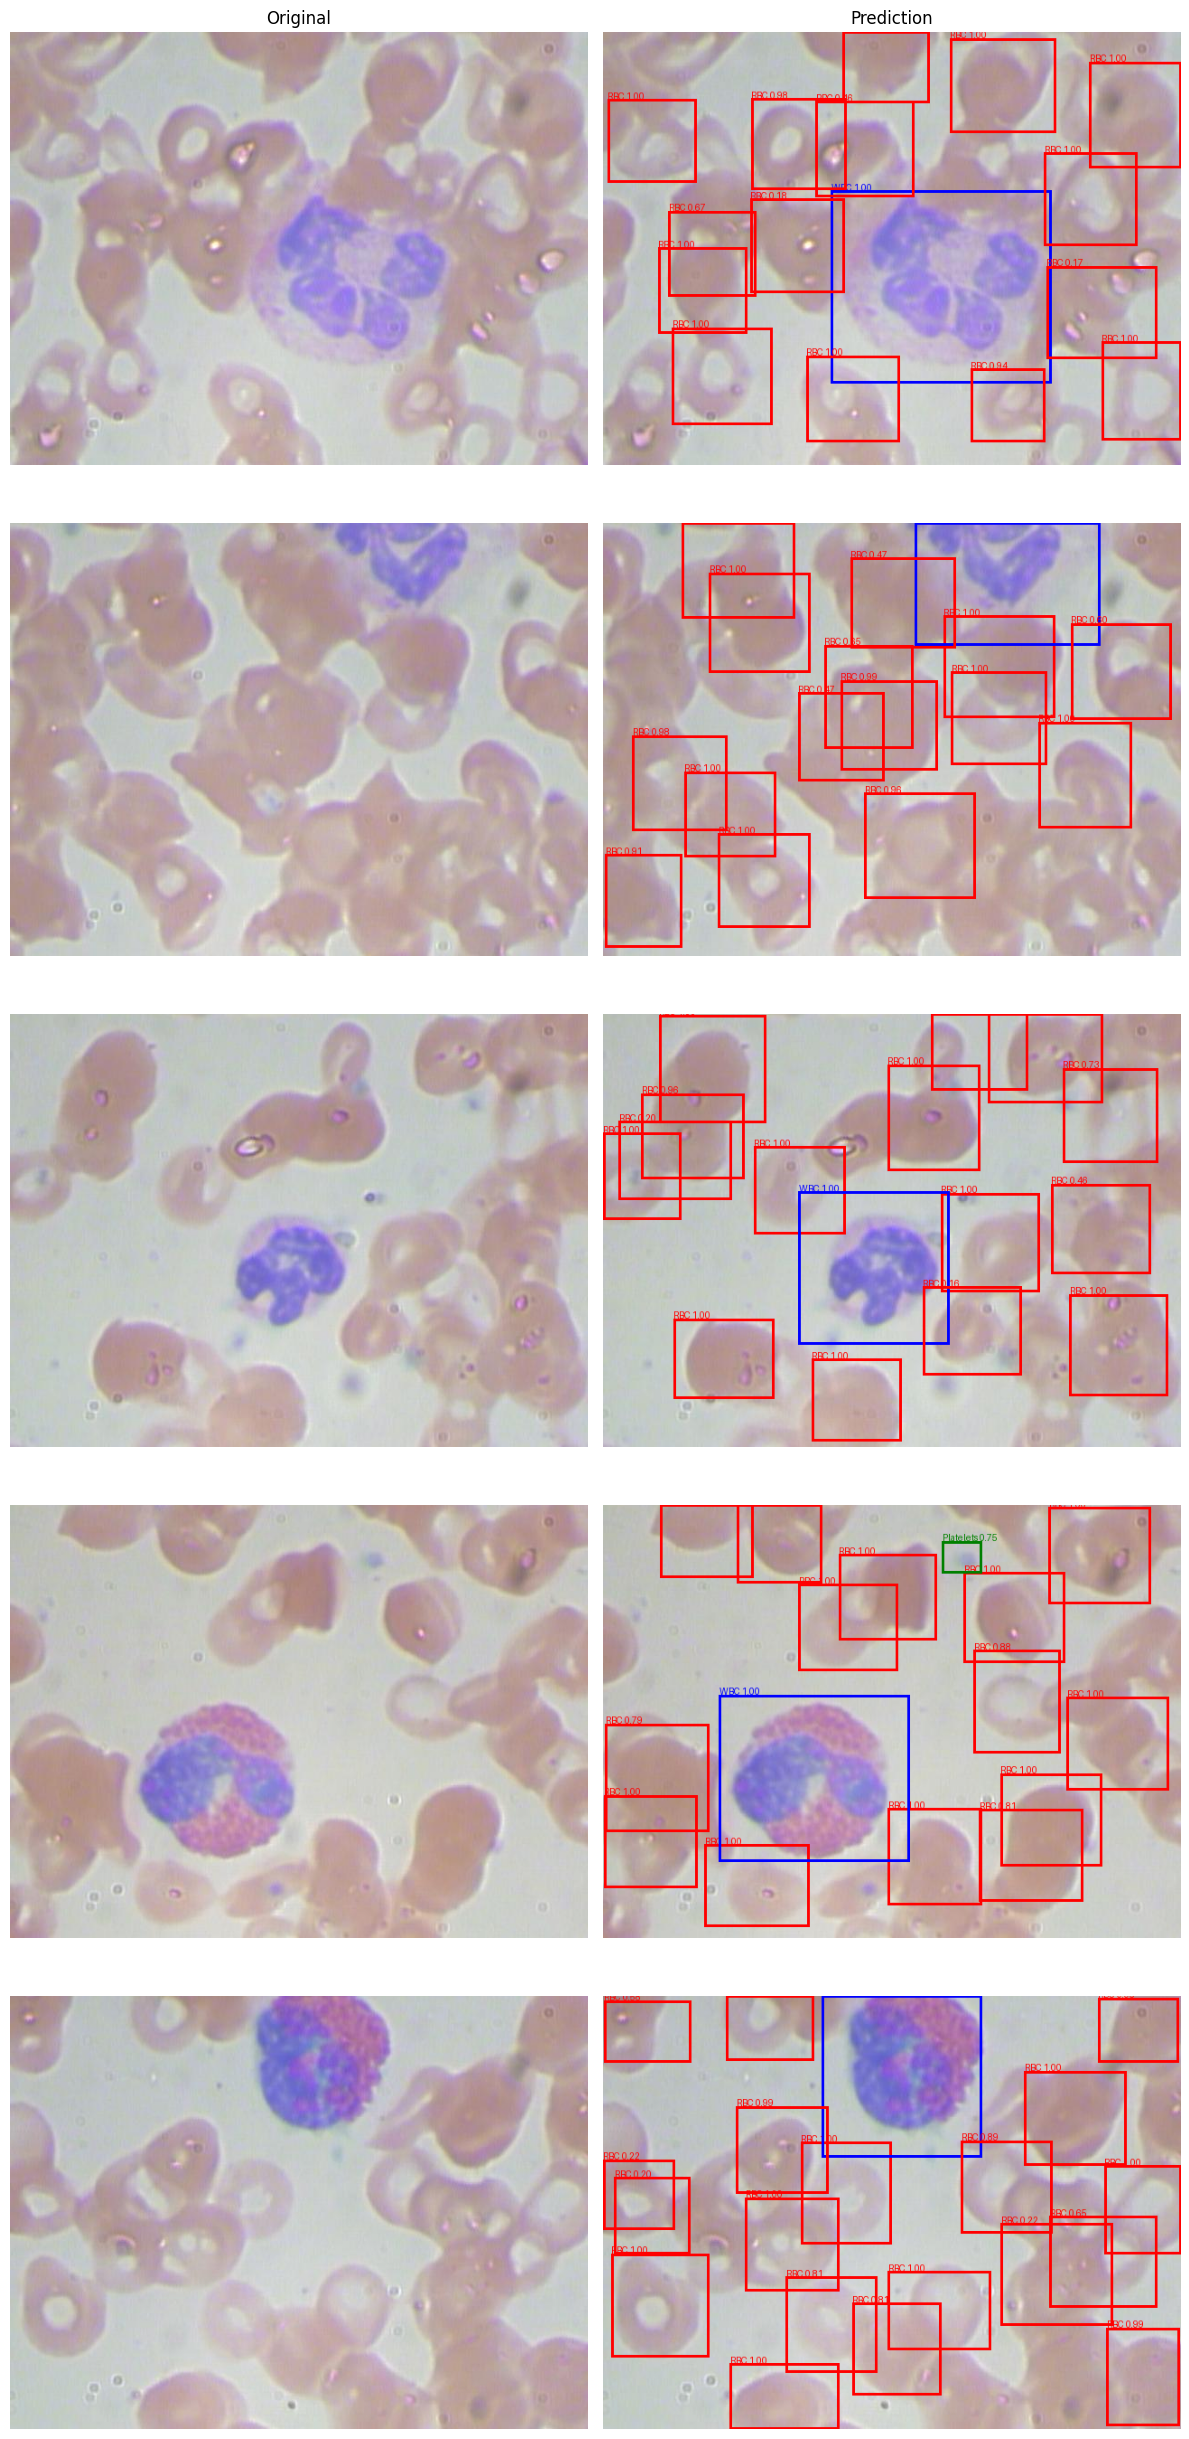

In [ ]:
from torchvision.models.detection import ssd300_vgg16
import warnings
warnings.filterwarnings("ignore")

num_classes = 4
model_ssd = ssd300_vgg16(weights_backbone='DEFAULT', num_classes=num_classes).to(device)

optimizer_ssd = torch.optim.Adam(model_ssd.parameters(), lr=1e-4)
epochs_ssd = 50

print("Обучение SSD")

for epoch in range(epochs_ssd):
    model_ssd.train()
    epoch_loss = 0
    for images, targets in train_loader_ssd:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        optimizer_ssd.zero_grad()
        loss_dict = model_ssd(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        losses.backward()
        optimizer_ssd.step()
        epoch_loss += losses.item()
        
    print(f"Epoch {epoch+1}/{epochs_ssd} | Loss: {epoch_loss / len(train_loader_ssd):.4f}")

model_ssd.eval()

test_images = []
for imgs, tgts in val_loader_ssd:
    test_images.extend(imgs)
    if len(test_images) >= 5:
        break
test_images = test_images[:5]

fig, axes = plt.subplots(5, 2, figsize=(12, 25))
colors = {1: 'red', 2: 'blue', 3: 'green'}
class_names = {1: 'RBC', 2: 'WBC', 3: 'Platelets'}

with torch.no_grad():
    for i in range(5):
        test_img = test_images[i].to(device)
        prediction = model_ssd([test_img])[0]
        
        mask = prediction['scores'] > 0.15
        boxes = prediction['boxes'][mask].cpu()
        labels = prediction['labels'][mask].cpu()
        scores = prediction['scores'][mask].cpu()

        img_pil_orig = FT.to_pil_image(test_img.cpu())
        img_pil_pred = img_pil_orig.copy()
        draw = ImageDraw.Draw(img_pil_pred)

        for box, label, score in zip(boxes, labels, scores):
            lbl_id = label.item()
            coords = box.tolist()
            draw.rectangle(coords, outline=colors[lbl_id], width=3)
            draw.text((coords[0], coords[1] - 10), f"{class_names[lbl_id]} {score:.2f}", fill=colors[lbl_id])
        
        axes[i, 0].imshow(img_pil_orig)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(img_pil_pred)
        axes[i, 1].axis('off')
        
        if i == 0:
            axes[i, 0].set_title('Original')
            axes[i, 1].set_title('Prediction')

plt.tight_layout()
plt.show()

Модели UNet и SSD обучены. UNet показывает высокую точность сегментации (0.95), а SSD демонстрирует сходимость функции потерь, и хорошо находит объекты на фото